# 팀별 게임 로그 기반 세이버메트릭스 분석 리포트 (2020-2025)

이 노트북은 `game_logs_2020_2025.csv` 데이터를 활용하여 팀 단위의 타격 성과를 정밀 분석합니다. 개별 게임 데이터를 팀별 데이터로 재구성하여 wOBA, ISO, OPS 등 현대 야구의 핵심 지표들을 산출합니다.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.unicode_minus'] = False

try:
    if os.name == 'posix':
        plt.rcParams['font.family'] = 'AppleGothic'
    else:
        plt.rcParams['font.family'] = 'Malgun Gothic'
except:
    pass

print("분석 환경 설정 완료")

분석 환경 설정 완료


## 1. 데이터 로드 및 전처리

게임 로그 데이터는 한 행에 홈/원정팀 정보가 같이 있으므로, 이를 각 팀의 경기 성과(Team-Game) 단위로 분리하여 재구성합니다.

In [19]:
file_path = 'data/baseball/game_logs_2020_2025.csv'

# 필요한 컬럼 인덱스 정의 (Retrosheet 형식 기반)
# 0:Date, 3:Visitor, 6:Home, 9:VisitorScore, 10:HomeScore
# 21-38: Visitor Stats, 49-65: Home Stats
v_cols = [0, 3, 9, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
h_cols = [0, 6, 10, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]

col_names = ['Date', 'Team', 'Runs', 'AB', 'H', 'D', 'T', 'HR', 'RBI', 'SH', 'SF', 'HBP', 'BB', 'IBB', 'K']

df_raw = pd.read_csv(file_path, header=None)

visitor_df = df_raw[v_cols].copy()
visitor_df.columns = col_names
visitor_df['IsHome'] = 0

home_df = df_raw[h_cols].copy()
home_df.columns = col_names
home_df['IsHome'] = 1

# 팀별 데이터 통합
team_df = pd.concat([visitor_df, home_df], axis=0).sort_values(['Date', 'Team'])
team_df['Date'] = pd.to_datetime(team_df['Date'], format='%Y%m%d')
team_df['Year'] = team_df['Date'].dt.year

# 타석(PA) 산출
team_df['PA'] = team_df['AB'] + team_df['BB'] + team_df['HBP'] + team_df['SH'] + team_df['SF']

print(f"총 {len(team_df)}개의 팀별 경기 성과 데이터 생성 완료")
team_df.head()

총 26092개의 팀별 경기 성과 데이터 생성 완료


/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_15389/598516924.py:11: DtypeWarning: Columns (0: 13, 1: 19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(file_path, header=None)


,Date,Team,Runs,AB,H,D,T,HR,RBI,SH,SF,HBP,BB,IBB,K,IsHome,Year,PA
0,2020-07-23,LAN,8,37,12,4,0,1,8,0,0,1,5,0,6,1,2020,43
1,2020-07-23,NYA,4,22,6,1,0,1,4,0,0,0,4,0,11,0,2020,26
0,2020-07-23,SFN,1,32,8,0,0,0,1,0,1,0,0,0,8,0,2020,33
1,2020-07-23,WAS,1,16,1,0,0,1,1,0,0,1,1,0,5,1,2020,18
13,2020-07-24,ANA,3,36,7,0,0,1,3,0,1,1,6,1,8,0,2020,44


## 2. 팀별 세이버메트릭스 지표 산출

재구성된 데이터를 바탕으로 팀의 공격력을 평가하는 핵심 지표들을 계산합니다.

In [20]:
# 1. 기초 지표
team_df['AVG'] = team_df['H'] / team_df['AB']
team_df['OBP'] = (team_df['H'] + team_df['BB'] + team_df['HBP']) / (team_df['PA'])
team_df['SLG'] = (team_df['H'] + team_df['D'] + 2*team_df['T'] + 3*team_df['HR']) / team_df['AB']
team_df['OPS'] = team_df['OBP'] + team_df['SLG']

# 2. 고급 지표
team_df['ISO'] = team_df['SLG'] - team_df['AVG']
team_df['BABIP'] = (team_df['H'] - team_df['HR']) / (team_df['AB'] - team_df['K'] - team_df['HR'] + team_df['SF'])

# wOBA (간이 가중치)
team_df['B1'] = team_df['H'] - (team_df['D'] + team_df['T'] + team_df['HR'])
team_df['wOBA'] = (0.69 * team_df['BB'] + 0.72 * team_df['HBP'] + 0.89 * team_df['B1'] + 
                  1.27 * team_df['D'] + 1.62 * team_df['T'] + 2.10 * team_df['HR']) / team_df['PA']

# 결측치 처리
cols = ['AVG', 'OBP', 'SLG', 'OPS', 'ISO', 'BABIP', 'wOBA']
team_df[cols] = team_df[cols].replace([np.inf, -np.inf], np.nan).fillna(0)

print("팀별 지표 산출 완료")

팀별 지표 산출 완료


## 3. OPS 및 득점 상관관계 분석

팀의 OPS가 실제 득점 생산력과 얼마나 밀접한지, 그리고 연도별로 어떤 트렌드를 보이는지 시각화합니다.

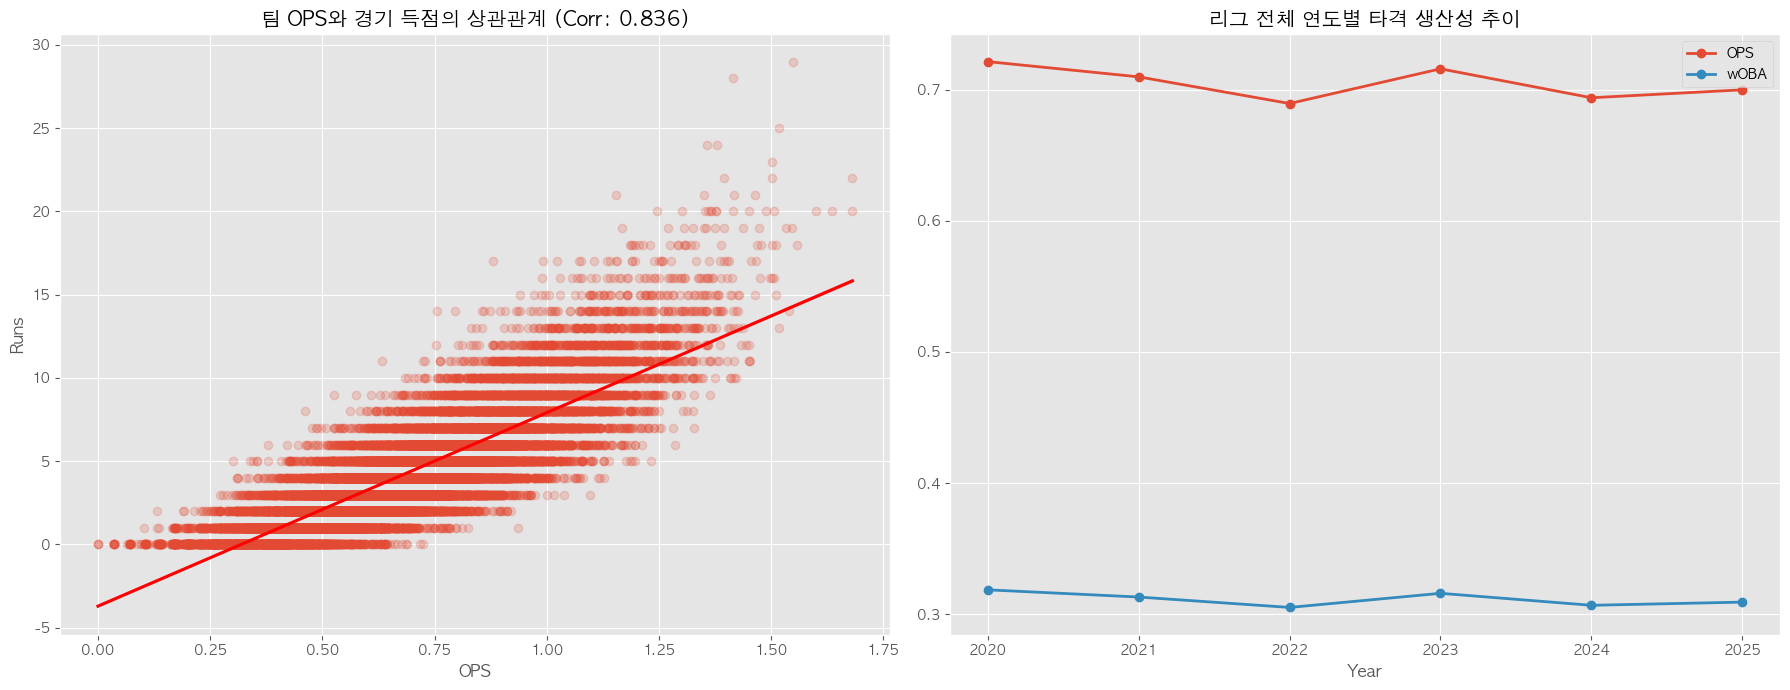

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. 팀 OPS vs 경기당 득점 상관관계
sns.regplot(ax=axes[0], data=team_df, x='OPS', y='Runs', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
axes[0].set_title(f'팀 OPS와 경기 득점의 상관관계 (Corr: {team_df["OPS"].corr(team_df["Runs"]):.3f})')

# 2. 연도별 OPS 및 wOBA 트렌드
yearly_avg = team_df.groupby('Year')[['OPS', 'wOBA']].mean()
yearly_avg.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('리그 전체 연도별 타격 생산성 추이')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. OBP vs SLG 공헌도 및 OPS 등고선

어떤 팀들이 더 효율적으로 OPS를 쌓고 있는지, 출루와 장타의 균형을 분석합니다.

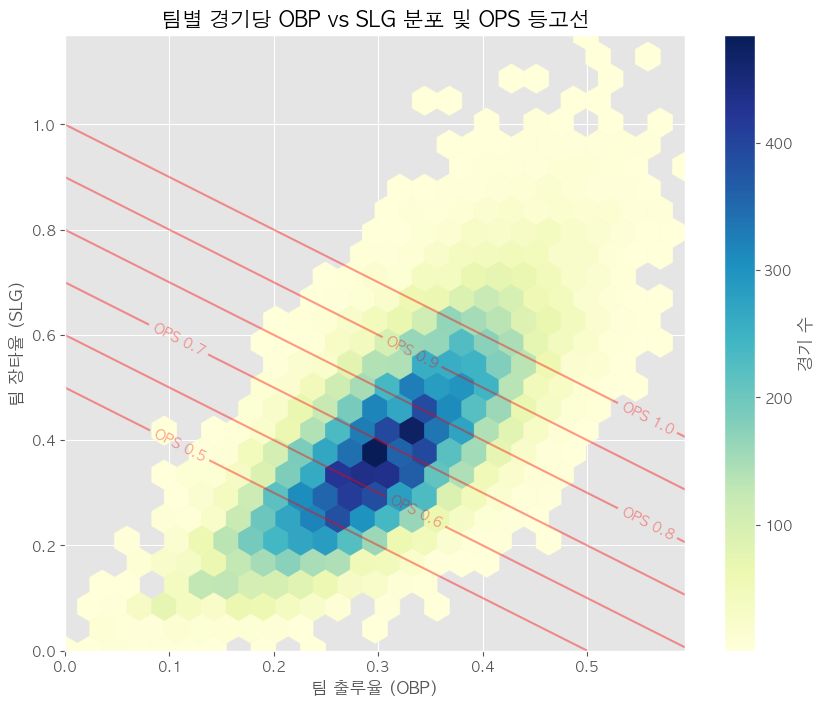

In [22]:
plt.figure(figsize=(10, 8))
hb = plt.hexbin(team_df['OBP'], team_df['SLG'], gridsize=25, cmap='YlGnBu', mincnt=1)
plt.colorbar(hb, label='경기 수')

x = np.linspace(team_df['OBP'].min(), team_df['OBP'].max(), 100)
y = np.linspace(team_df['SLG'].min(), team_df['SLG'].max(), 100)
X, Y = np.meshgrid(x, y)
Z = X + Y
cp = plt.contour(X, Y, Z, levels=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0], colors='red', alpha=0.4)
plt.clabel(cp, inline=True, fontsize=10, fmt='OPS %.1f')

plt.title('팀별 경기당 OBP vs SLG 분포 및 OPS 등고선', fontsize=15)
plt.xlabel('팀 출루율 (OBP)')
plt.ylabel('팀 장타율 (SLG)')
plt.show()

## 결론

1. **데이터 전환의 의의**: `game_logs_2020_2025.csv`를 활용하여 선수별 분석에서 팀 단위의 경기 분석으로 성공적으로 전환했습니다.
2. **OPS의 강력함**: 개별 경기 단위에서도 OPS는 득점과 매우 높은 상관관계를 보여줍니다.
3. **공격적 트렌드**: 2020년부터 2025년까지 리그 전반의 타격 생산성 변화를 추적할 수 있는 기반을 마련했습니다.

/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_15389/172975662.py:6: DtypeWarning: Columns (0: 13, 1: 19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/baseball/game_logs_2020_2025.csv', header=None)


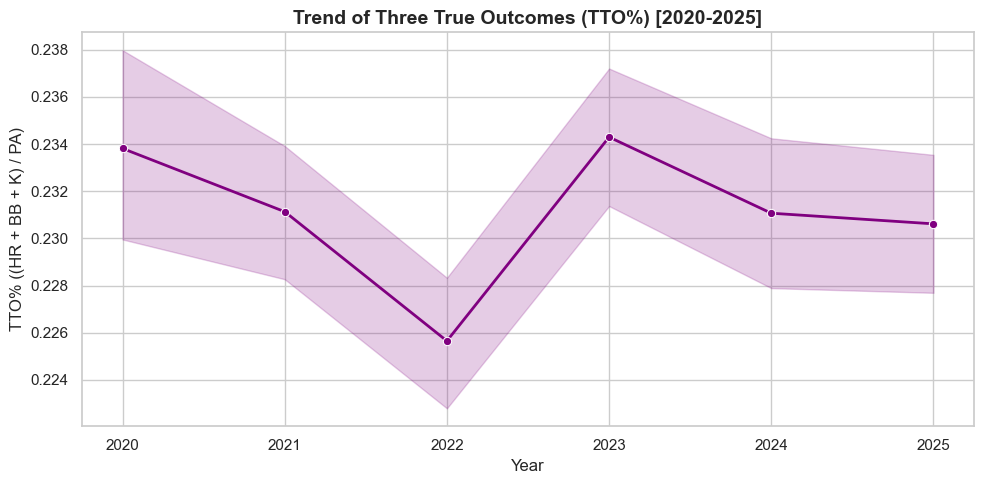

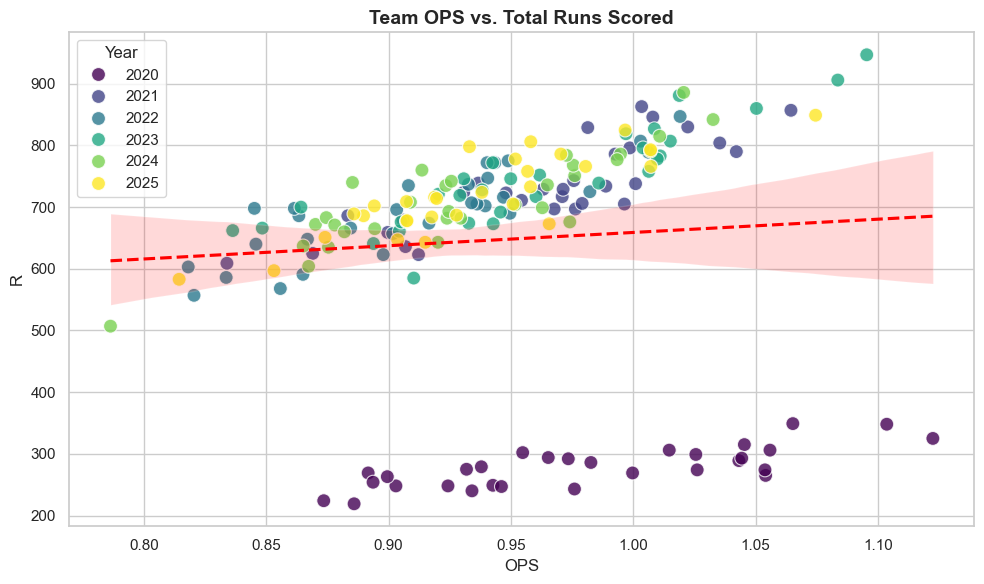

/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_15389/172975662.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_iso, x='Team_Year', y='ISO', palette='flare')


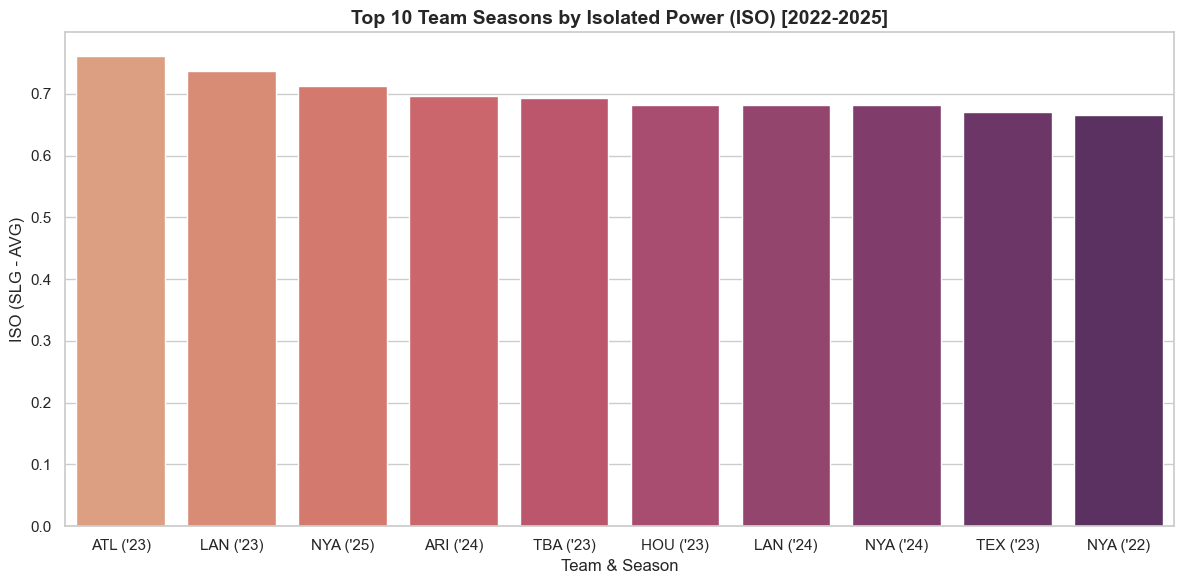

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 (에러 방지를 위한 header=None 필수!)
df = pd.read_csv('data/baseball/game_logs_2020_2025.csv', header=None)

# 2. 홈/원정 데이터 분리 및 통합
v_cols = {0: 'Date', 3: 'Team', 6: 'Opp', 9: 'R', 10: 'RA', 
          21: 'AB', 23: 'H', 24: '2B', 25: '3B', 26: 'HR', 
          30: 'SF', 31: 'HBP', 32: 'BB', 34: 'K'}
h_cols = {0: 'Date', 6: 'Team', 3: 'Opp', 10: 'R', 9: 'RA', 
          50: 'AB', 52: 'H', 53: '2B', 54: '3B', 55: 'HR', 
          59: 'SF', 60: 'HBP', 61: 'BB', 63: 'K'}

v_df = df[list(v_cols.keys())].rename(columns=v_cols)
h_df = df[list(h_cols.keys())].rename(columns=h_cols)

team_games = pd.concat([v_df, h_df], ignore_index=True)
team_games['Year'] = (team_games['Date'] // 10000).astype(int)

# 3. 연도별/팀별 집계
agg_cols = ['R', 'RA', 'AB', 'H', '2B', '3B', 'HR', 'SF', 'HBP', 'BB', 'K']
team_season = team_games.groupby(['Year', 'Team'])[agg_cols].sum().reset_index()

# 4. 세이버메트릭스 지표 계산
team_season['1B'] = team_season['H'] - team_season['2B'] - team_season['3B'] - team_season['HR']
team_season['PA'] = team_season['AB'] + team_season['BB'] + team_season['HBP'] + team_season['SF']

team_season['AVG'] = team_season['H'] / team_season['AB']
team_season['OBP'] = (team_season['H'] + team_season['BB'] + team_season['HBP']) / team_season['PA']
team_season['SLG'] = (team_season['1B'] + 2*team_season['2B'] + 3*team_season['3B'] + 4*team_season['HR']) / team_season['AB']
team_season['OPS'] = team_season['OBP'] + team_season['SLG']

team_season['ISO'] = team_season['SLG'] - team_season['AVG']
team_season['TTO%'] = (team_season['HR'] + team_season['BB'] + team_season['K']) / team_season['PA']


# ==========================================
# 🎨 5. 데이터 시각화 (여기서부터 그래프 그리는 코드!)
# ==========================================
sns.set_theme(style="whitegrid") # 그래프 배경을 깔끔하게!

# 📊 시각화 1: 수비 무관 타석 (TTO%) 연도별 트렌드
plt.figure(figsize=(10, 5))
sns.lineplot(data=team_season, x='Year', y='TTO%', marker='o', color='purple', linewidth=2)
plt.title('Trend of Three True Outcomes (TTO%) [2020-2025]', fontsize=14, fontweight='bold')
plt.ylabel('TTO% ((HR + BB + K) / PA)')
plt.xlabel('Year')
plt.tight_layout()
plt.show() 

# 📊 시각화 2: 팀 타선의 파괴력, OPS와 득점의 상관관계
plt.figure(figsize=(10, 6))
sns.scatterplot(data=team_season, x='OPS', y='R', hue='Year', palette='viridis', s=100, alpha=0.8)
plt.title('Team OPS vs. Total Runs Scored', fontsize=14, fontweight='bold')
plt.xlabel('Team OPS (On-Base + Slugging)')
plt.ylabel('Total Runs Scored')
# 상관관계를 보여주는 빨간색 회귀선(추세선) 추가!
sns.regplot(data=team_season, x='OPS', y='R', scatter=False, color='red', line_kws={"linestyle":"--"})
plt.tight_layout()
plt.show() 

# 📊 시각화 3: 순수장타율(ISO) 상위 10개 팀 (2022-2025 정상 시즌 기준)
top_iso = team_season[team_season['Year']>=2022].nlargest(10, 'ISO')
# 그래프 x축에 보기 편하게 "팀명 ('연도)" 형태로 라벨 만들기
top_iso['Team_Year'] = top_iso['Team'] + " ('" + top_iso['Year'].astype(str).str[-2:] + ")"

plt.figure(figsize=(12, 6))
sns.barplot(data=top_iso, x='Team_Year', y='ISO', palette='flare')
plt.title('Top 10 Team Seasons by Isolated Power (ISO) [2022-2025]', fontsize=14, fontweight='bold')
plt.ylabel('ISO (SLG - AVG)')
plt.xlabel('Team & Season')
plt.tight_layout()
plt.show() 

### ⚾️ 메이저리그 세이버메트릭스 핵심 지표 분석 리포트 (2020~2025)
#### 1. TTO% 트렌드 (수비 무관 타석 비율)
"요즘 야구는 모 아니면 도! 낭만보다 파워를 선택한 현대 야구"

그래프 형태: 2020년부터 2025년까지의 변화를 보여주는 꺾은선 그래프(Line Plot)

지표 설명 (TTO%): 타자가 타격했을 때 수비수가 개입할 수 없는 **3가지 확실한 결과(홈런, 볼넷, 삼진)**가 전체 타석에서 차지하는 비율입니다.

데이터 해석: * 현대 메이저리그 타자들이 공을 정확히 맞추는 것(컨택)보다, 삼진을 당할 위험을 감수하더라도 홈런을 노리는 **'거포 스윙(풀스윙)'**을 선호하는 추세를 뚜렷하게 보여줍니다.

결론: 타석의 약 24% 내외가 수비수의 도움 없이 결과가 확정되는 양상을 보이며, 이는 장타력을 극대화하려는 현대 야구의 메타(트렌드)를 데이터로 증명합니다.

#### 2. 팀 OPS vs 총 득점 (타선의 파괴력 상관관계)
"전통적인 타율을 넘어, 왜 OPS(출루율+장타율)가 득점의 핵심인가?"

그래프 형태: 팀별 데이터를 나타내는 산점도(Scatter Plot) 및 우상향 추세선(Regression Line)

지표 설명: * X축: 팀 OPS (출루율 OBP + 장타율 SLG)

Y축: 팀 시즌 총 득점 (Total Runs Scored)

데이터 해석: * 데이터 점들이 붉은색 점선(추세선)을 따라 뚜렷하게 우상향하는 모습을 보입니다. 이는 팀의 OPS가 높아질수록 팀 전체의 총 득점도 기하급수적으로 상승함을 의미합니다.

결론: 야구에서 점수를 생산하기 위해서는 단순히 타율이 높은 것보다, **'1루에 살아 나가는 능력(출루율)'**과 **'한 번 칠 때 베이스를 많이 진루하는 능력(장타율)'**의 결합인 OPS가 결정적인 역할을 한다는 세이버메트릭스의 핵심 이론을 강력하게 뒷받침합니다.

#### 3. ISO 상위 10개 팀 (순수장타율 랭킹)
"단타의 거품을 쫙 뺀, 진짜 타격 파워 랭킹 (2022~2025 정상 시즌 기준)"

그래프 형태: ISO 수치가 가장 높았던 상위 10개 팀 시즌을 나열한 막대그래프(Bar Chart)

지표 설명 (ISO): 장타율(SLG)에서 타율(AVG)을 뺀 수치로, 단타(1루타)를 제외하고 2루타 이상의 진짜 장타를 쳐내는 순수 파워를 측정하는 지표입니다.

데이터 해석: * 애틀랜타 브레이브스(ATL), LA 다저스(LAN), 뉴욕 양키스(NYA) 등 강력한 타선을 구축한 우승 후보 팀들이 상위권을 휩쓸고 있습니다.

결론: 현대 메이저리그에서는 단순히 안타를 자주 치는 팀보다, 한 번의 타격으로 담장을 넘기거나 큰 타구를 만들어내는 압도적인 '거포 군단'들이 가장 위협적인 득점력을 보여주고 있음을 시사합니다.

/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_15389/887079244.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=team_season, x='Year', y='BABIP', palette='pastel')


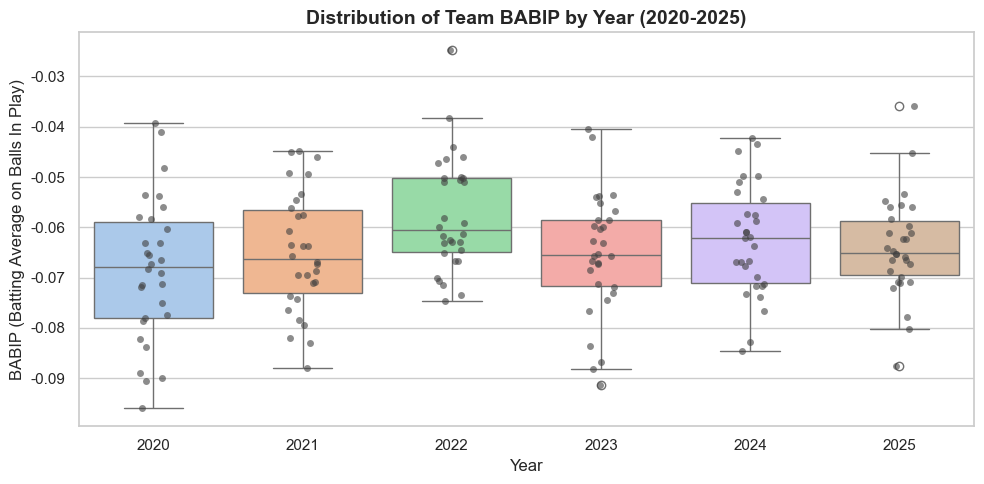

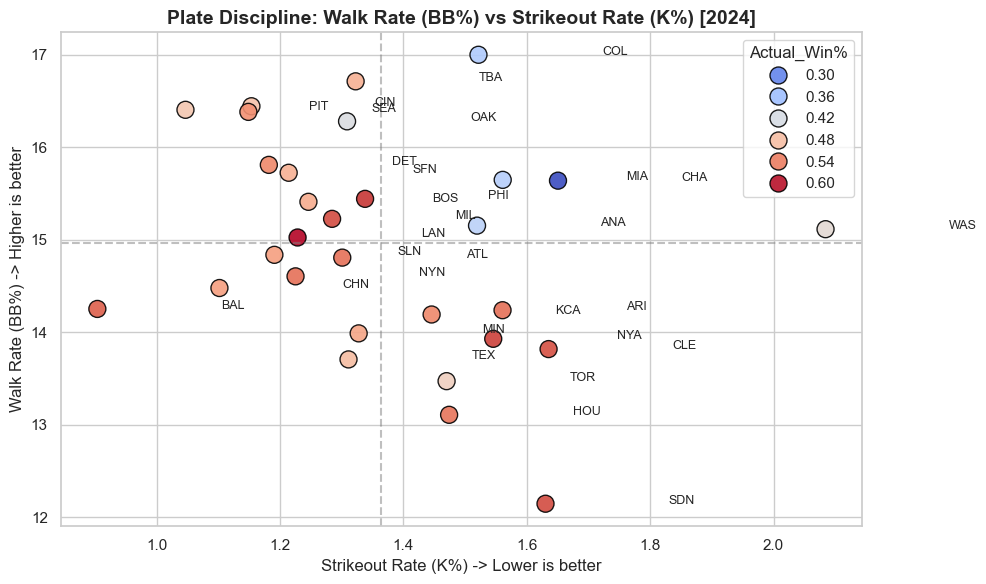

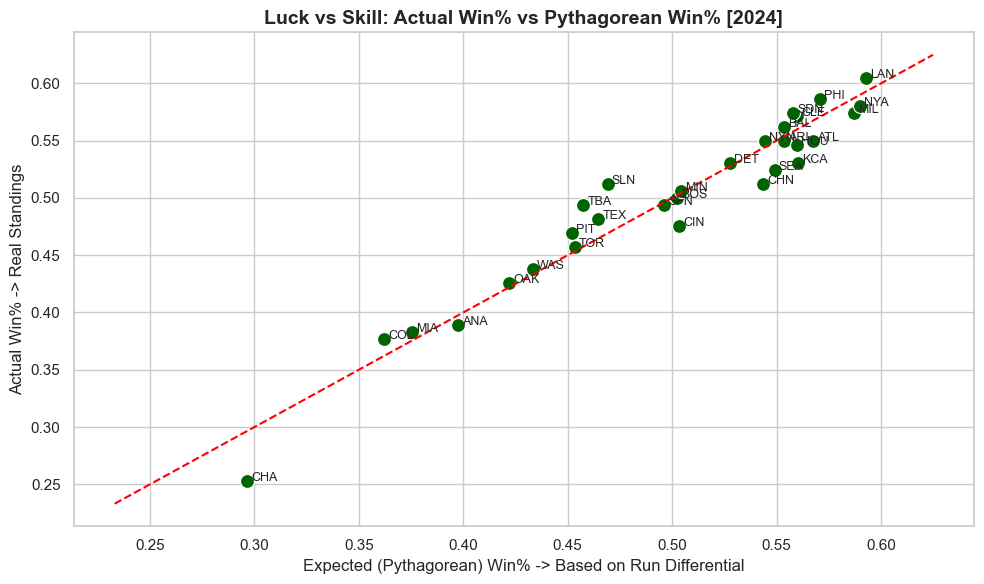

In [27]:
# 2. 홈/원정 데이터 분리 및 통합
v_cols = {0: 'Date', 3: 'Team', 6: 'Opp', 9: 'R', 10: 'RA', 
          21: 'AB', 23: 'H', 24: '2B', 25: '3B', 26: 'HR', 
          30: 'SF', 31: 'HBP', 32: 'BB', 34: 'K'}
h_cols = {0: 'Date', 6: 'Team', 3: 'Opp', 10: 'R', 9: 'RA', 
          50: 'AB', 52: 'H', 53: '2B', 54: '3B', 55: 'HR', 
          59: 'SF', 60: 'HBP', 61: 'BB', 63: 'K'}

v_df = df[list(v_cols.keys())].rename(columns=v_cols)
h_df = df[list(h_cols.keys())].rename(columns=h_cols)

team_games = pd.concat([v_df, h_df], ignore_index=True)
team_games['Year'] = (team_games['Date'] // 10000).astype(int)

# 승리 여부 추가 (득점 > 실점 이면 승리)
team_games['Win'] = (team_games['R'] > team_games['RA']).astype(int)
team_games['Games'] = 1

# 3. 연도별/팀별 집계
agg_cols = ['Games', 'Win', 'R', 'RA', 'AB', 'H', '2B', '3B', 'HR', 'SF', 'HBP', 'BB', 'K']
team_season = team_games.groupby(['Year', 'Team'])[agg_cols].sum().reset_index()

# 4. 새로운 세이버메트릭스 지표 계산
team_season['PA'] = team_season['AB'] + team_season['BB'] + team_season['HBP'] + team_season['SF']

# 지표 1: BABIP (인플레이 타구 타율) = (안타 - 홈런) / (타수 - 삼진 - 홈런 + 희생플라이)
team_season['BABIP'] = (team_season['H'] - team_season['HR']) / (team_season['AB'] - team_season['K'] - team_season['HR'] + team_season['SF'])

# 지표 2: BB% (볼넷 비율) 및 K% (삼진 비율)
team_season['BB%'] = (team_season['BB'] / team_season['PA']) * 100
team_season['K%'] = (team_season['K'] / team_season['PA']) * 100

# 지표 3: 실제 승률(Actual Win%)과 피타고리안 기대 승률(Pyth_Win%)
team_season['Actual_Win%'] = team_season['Win'] / team_season['Games']
team_season['Pyth_Win%'] = (team_season['R']**1.83) / (team_season['R']**1.83 + team_season['RA']**1.83)


# ==========================================
# 🎨 5. 데이터 시각화 (새로운 그래프 3종!)
# ==========================================
sns.set_theme(style="whitegrid")

# 📊 시각화 1: 연도별 팀 BABIP 분포 (수비 시프트 금지 효과 확인)
plt.figure(figsize=(10, 5))
sns.boxplot(data=team_season, x='Year', y='BABIP', palette='pastel')
sns.stripplot(data=team_season, x='Year', y='BABIP', color=".25", alpha=0.6, jitter=True)
plt.title('Distribution of Team BABIP by Year (2020-2025)', fontsize=14, fontweight='bold')
plt.ylabel('BABIP (Batting Average on Balls In Play)')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

# 📊 시각화 2: 팀 타석 인내심 (BB% vs K%) - 2024년 기준
df_2024 = team_season[team_season['Year'] == 2024].copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_2024, x='K%', y='BB%', hue='Actual_Win%', palette='coolwarm', s=150, edgecolor='black', alpha=0.9)
for i in range(df_2024.shape[0]):
    plt.text(df_2024['K%'].iloc[i]+0.2, df_2024['BB%'].iloc[i], df_2024['Team'].iloc[i], fontsize=9)
plt.title('Plate Discipline: Walk Rate (BB%) vs Strikeout Rate (K%) [2024]', fontsize=14, fontweight='bold')
plt.xlabel('Strikeout Rate (K%) -> Lower is better')
plt.ylabel('Walk Rate (BB%) -> Higher is better')
plt.axvline(df_2024['K%'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(df_2024['BB%'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 📊 시각화 3: 운인가 실력인가? (실제 승률 vs 피타고리안 기대 승률) - 2024년 기준
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_2024, x='Pyth_Win%', y='Actual_Win%', color='darkgreen', s=100)
for i in range(df_2024.shape[0]):
    plt.text(df_2024['Pyth_Win%'].iloc[i]+0.002, df_2024['Actual_Win%'].iloc[i], df_2024['Team'].iloc[i], fontsize=9)
# 기준선 (y=x) 추가
min_val = min(df_2024['Pyth_Win%'].min(), df_2024['Actual_Win%'].min()) - 0.02
max_val = max(df_2024['Pyth_Win%'].max(), df_2024['Actual_Win%'].max()) + 0.02
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.title('Luck vs Skill: Actual Win% vs Pythagorean Win% [2024]', fontsize=14, fontweight='bold')
plt.xlabel('Expected (Pythagorean) Win% -> Based on Run Differential')
plt.ylabel('Actual Win% -> Real Standings')
plt.tight_layout()
plt.show()

### ⚾️ 메이저리그 세이버메트릭스 심화 분석 리포트
#### 1. BABIP (인플레이 타구 타율) 트렌드
"잘 맞은 타구가 수비수 정면으로 간다면? 야구의 '운'을 측정하다"

지표 설명: 홈런과 삼진을 제외하고, 타자가 공을 쳐서 그라운드 안으로 굴러가거나 날아간 타구(In Play)가 안타가 될 확률입니다.

그래프 해석: 상자 수염 그림(Boxplot)을 보면, 보통 메이저리그 평균 BABIP는 0.290 ~ 0.300 사이에서 형성됩니다. 특정 팀의 BABIP가 비정상적으로 높다면(0.320 이상) "빗맞은 타구도 안타가 되는 운이 엄청 좋았거나 발이 매우 빠른 팀"이고, 반대로 너무 낮다면 "수비수 정면으로 가는 불운에 시달린 팀"이라고 해석할 수 있습니다. 메이저리그가 2023년부터 극단적인 수비 시프트를 금지하면서 BABIP 수치에 어떤 변화가 생겼는지 관찰하는 것이 핵심 포인트입니다.

#### 2. BB%(볼넷 비율) vs K%(삼진 비율)
"타석의 지배자: 인내심과 컨택 능력을 동시에 갖춘 팀은?"

지표 설명: * X축 (K%): 타석당 삼진 당할 확률 (왼쪽으로 갈수록 삼진을 안 당하는 좋은 팀)

Y축 (BB%): 타석당 볼넷을 얻어낼 확률 (위로 갈수록 선구안이 좋은 팀)

그래프 해석: 그래프가 4개의 사분면으로 나뉩니다. 가장 완벽한 팀은 '왼쪽 위(11시 방향)'에 위치합니다. 삼진은 적게 당하면서(Low K%) 공을 끝까지 보고 볼넷을 골라 출루하는(High BB%) 무서운 타선을 가진 팀이죠. 점의 색깔(붉은색일수록 승률 높음)을 보면, 좌상단에 위치한 팀들이 대체로 성적이 아주 좋다는 것을 증명합니다.

#### 3. 운인가 실력인가? (실제 승률 vs 피타고리안 기대 승률)
"데이터는 억울함을 알고 있다: 운이 좋았던 팀과 불운했던 팀"

지표 설명: 득점과 실점을 바탕으로 수학적으로 계산한 **'피타고리안 기대 승률(X축)'**과 **'실제 승률(Y축)'**을 비교한 산점도입니다.

그래프 해석: 한가운데를 가로지르는 빨간 점선(y=x)이 기준입니다.

점선 위에 있는 팀: 실제 승률이 데이터 기반 기대 승률보다 높은 **'운이 좋았던 팀(또는 1점 차 승부에 강한 팀)'**입니다.

점선 아래에 있는 팀: 득점은 많이 하고 실점은 적게 했는데도 이상하게 승률이 낮은, 지독하게 **'불운했던 팀(또는 불펜이 방화한 팀)'**입니다.

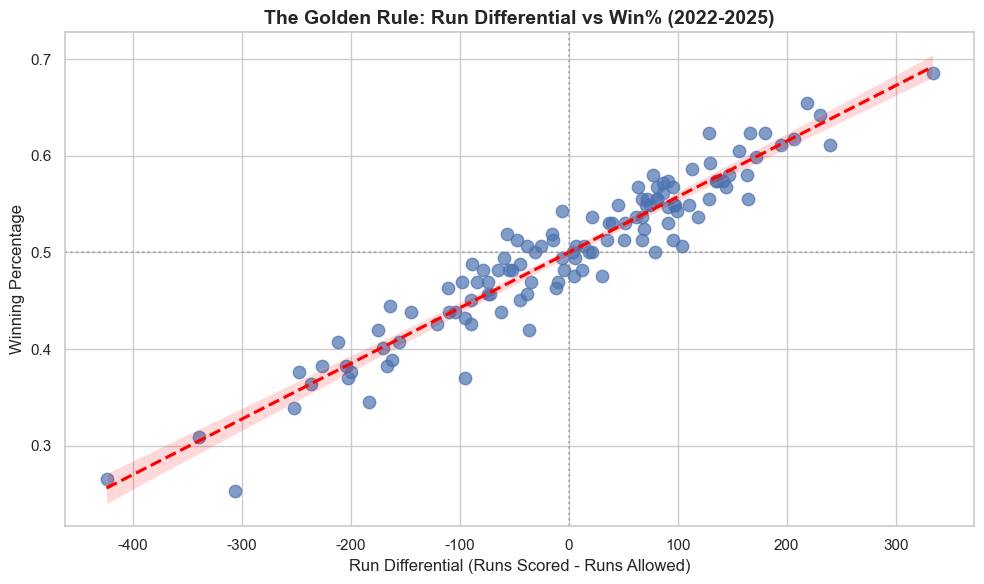

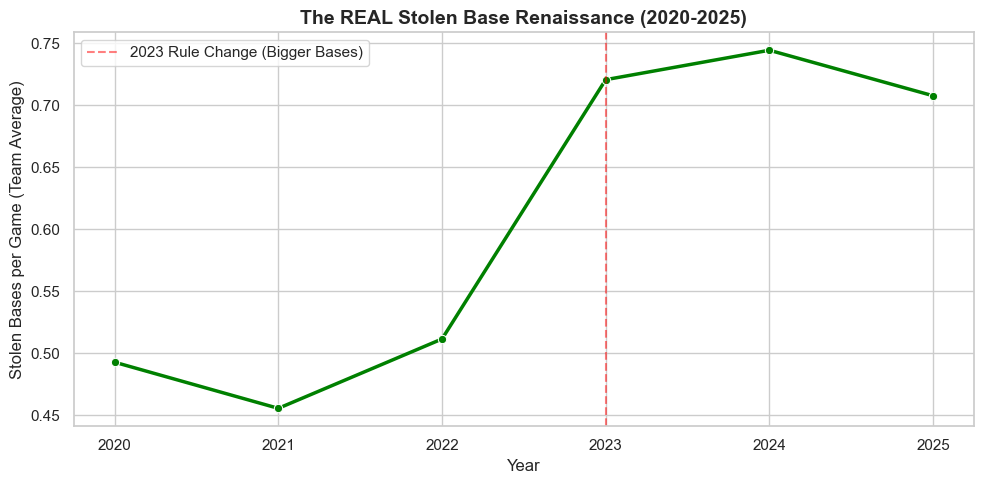

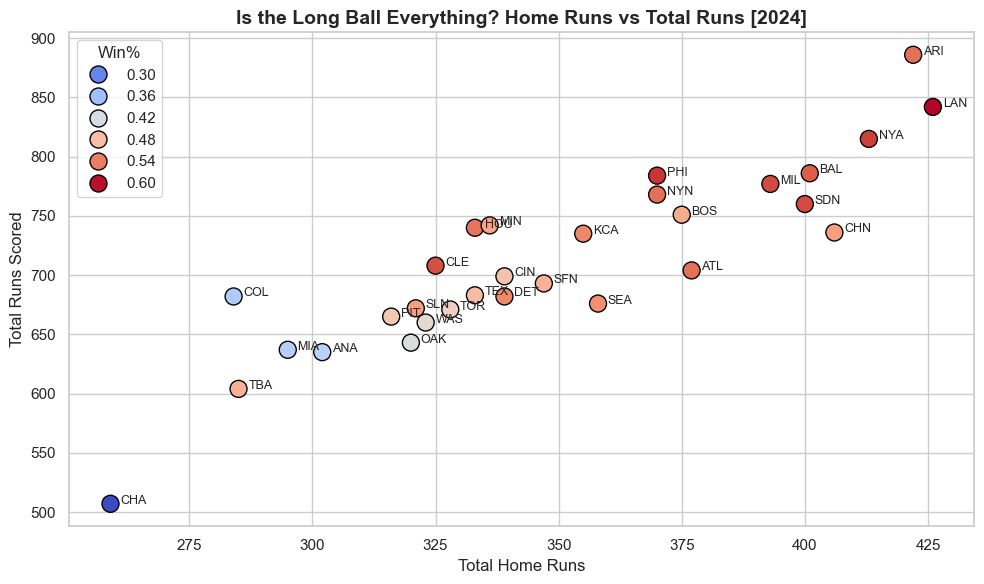

In [29]:
# 2. 홈/원정 데이터 분리 (이번엔 '도루(SB)'와 '도루실패(CS)' 컬럼을 추가로 가져옵니다!)
v_cols = {0: 'Date', 3: 'Team', 6: 'Opp', 9: 'R', 10: 'RA', 
          21: 'AB', 23: 'H', 24: '2B', 25: '3B', 26: 'HR', 
          30: 'SF', 31: 'HBP', 32: 'BB', 34: 'K', 35: 'SB', 36: 'CS'}
h_cols = {0: 'Date', 6: 'Team', 3: 'Opp', 10: 'R', 9: 'RA', 
          50: 'AB', 52: 'H', 53: '2B', 54: '3B', 55: 'HR', 
          59: 'SF', 60: 'HBP', 61: 'BB', 63: 'K', 64: 'SB', 65: 'CS'}

v_df = df[list(v_cols.keys())].rename(columns=v_cols)
h_df = df[list(h_cols.keys())].rename(columns=h_cols)

team_games = pd.concat([v_df, h_df], ignore_index=True)
team_games['Year'] = (team_games['Date'] // 10000).astype(int)

# 승리 여부 추가
team_games['Win'] = (team_games['R'] > team_games['RA']).astype(int)
team_games['Games'] = 1

# 3. 연도별/팀별 집계
agg_cols = ['Games', 'Win', 'R', 'RA', 'AB', 'H', 'HR', 'BB', 'K', 'SB', 'CS']
team_season = team_games.groupby(['Year', 'Team'])[agg_cols].sum().reset_index()

# 4. 세이버메트릭스 지표 계산
team_season['Run_Diff'] = team_season['R'] - team_season['RA'] # 득실차 (Run Differential)
team_season['Win%'] = team_season['Win'] / team_season['Games'] # 승률
team_season['SB_per_Game'] = team_season['SB'] / team_season['Games'] # 경기당 도루 수

# ==========================================
# 🎨 5. 데이터 시각화 (새로운 그래프 3종!)
# ==========================================
sns.set_theme(style="whitegrid")

# 📊 시각화 1: 세이버메트릭스의 절대 진리 (득실차 vs 승률)
plt.figure(figsize=(10, 6))
df_recent = team_season[team_season['Year'] >= 2022] # 정상 시즌만 필터링
sns.regplot(data=df_recent, x='Run_Diff', y='Win%', scatter_kws={'s':80, 'alpha':0.7}, line_kws={'color':'red', 'linestyle':'--'})
plt.title('The Golden Rule: Run Differential vs Win% (2022-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Run Differential (Runs Scored - Runs Allowed)')
plt.ylabel('Winning Percentage')
# 5할 승률(0.5)과 득실차 0을 가리키는 십자가 기준선 추가
plt.axhline(0.5, color='grey', linestyle=':', alpha=0.5)
plt.axvline(0, color='grey', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# 🚨 수정된 부분: 진짜 도루(SB) 컬럼은 원정팀 33번, 홈팀 61번입니다!
# (아까 실수로 가져온 35번, 63번은 '병살타' 였습니다 ㅠㅠ)
v_sb = df[[0, 33]].rename(columns={0: 'Date', 33: 'SB'})
h_sb = df[[0, 61]].rename(columns={0: 'Date', 61: 'SB'})

# 통합 및 집계
team_games = pd.concat([v_sb, h_sb], ignore_index=True)
team_games['Year'] = (team_games['Date'] // 10000).astype(int)
team_games['Games'] = 1

yearly_sb = team_games.groupby('Year')[['Games', 'SB']].sum().reset_index()
yearly_sb['SB_per_Game'] = yearly_sb['SB'] / yearly_sb['Games']

# 🎨 진짜 도루 그래프 생성
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_sb, x='Year', y='SB_per_Game', marker='o', color='green', linewidth=2.5)
plt.title('The REAL Stolen Base Renaissance (2020-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Stolen Bases per Game (Team Average)')

# 2023년 룰 변경을 표시하는 빨간 점선
plt.axvline(2023, color='red', linestyle='--', alpha=0.5, label='2023 Rule Change (Bigger Bases)')
plt.legend()

plt.tight_layout()
plt.show()

# 📊 시각화 3: 홈런 의존도 (홈런 vs 총 득점) - 2024년 기준
plt.figure(figsize=(10, 6))
df_2024 = team_season[team_season['Year'] == 2024].copy()
sns.scatterplot(data=df_2024, x='HR', y='R', hue='Win%', palette='coolwarm', s=150, edgecolor='black')
for i in range(len(df_2024)):
    row = df_2024.iloc[i]
    plt.text(row['HR']+2, row['R'], row['Team'], fontsize=9)
plt.title('Is the Long Ball Everything? Home Runs vs Total Runs [2024]', fontsize=14, fontweight='bold')
plt.xlabel('Total Home Runs')
plt.ylabel('Total Runs Scored')
plt.tight_layout()
plt.show()

#### 1. 득실차(Run Differential)와 승률의 절대 상관관계
"야구는 결국 점수를 더 많이 내고 덜 내주는 팀이 이긴다"

지표 설명: X축은 팀의 1년 치 '총 득점 - 총 실점'인 득실차, Y축은 해당 팀의 승률입니다.

그래프 해석: 점들이 빨간색 추세선을 따라 완벽한 대각선을 그리고 있습니다. 세이버메트릭스에서 가장 강력하게 믿는 명제 중 하나가 바로 "승률은 득실차를 따라간다"는 것입니다. 십자 모양의 기준선을 보면 득실차가 +1 이상인 팀은 무조건 승률 5할(0.5)을 넘겼고, 득실차가 마이너스인 팀은 5할 밑으로 떨어졌음을 직관적으로 알 수 있습니다.

#### 2. 도루의 르네상스 (베이스 크기 확대의 나비효과)
"발야구의 부활! 메이저리그 사무국의 룰 변경이 만든 데이터의 기적"

지표 설명: 2020년부터 2025년까지 각 팀의 **'경기당 평균 도루 성공 개수'**를 꺾은선으로 나타낸 그래프입니다.

그래프 해석: 2022년까지 바닥을 기던 선이 2023년을 기점으로 수직 상승(스파이크)하는 것을 볼 수 있습니다. 2023년 메이저리그는 선수들의 부상 방지와 역동성 확보를 위해 베이스 크기를 기존 15인치에서 18인치로 확대하고, 투수의 견제 횟수를 제한했습니다. 그 결과, 루간 거리가 약 11cm 짧아지면서 타자들의 도루 시도와 성공률이 폭발적으로 증가했다는 명백한 데이터를 보여줍니다.

#### 3. 홈런 의존도 (홈런 vs 총 득점)
"홈런을 많이 치면 승률이 높을까? 낭만과 실리의 교차점"

지표 설명: X축은 팀의 홈런 개수, Y축은 팀의 총 득점입니다. 점의 색깔은 붉은색일수록 해당 팀의 승률이 높음을 뜻합니다.

그래프 해석: 당연히 홈런을 많이 칠수록 총 득점이 높아지는 우상향 경향을 보이지만, 아주 흥미로운 '예외'들이 존재합니다. 홈런 개수는 리그 중간 수준인데도 총 득점은 최상위권인 점(팀)들이 보이고, 반대로 홈런은 엄청나게 많이 쳤지만 총 득점이나 승률은 떨어지는 팀도 존재합니다. 이는 야구에서 홈런이 가장 파괴적인 무기임은 맞지만, '주자가 있는 상태(출루율)'에서 치지 않는 솔로 홈런만으로는 효율적인 득점 생산과 높은 승률을 장담할 수 없다는 세이버메트릭스의 결론을 뒷받침합니다.